In [20]:
from google.colab import files
uploaded = files.upload()

Saving final_dataset_with_real_and_normalised_time.xlsx to final_dataset_with_real_and_normalised_time.xlsx


In [25]:
import pandas as pd

df = pd.read_excel("final_dataset_with_real_and_normalised_time.xlsx")

df.head()

,OS,Run_ID,Num_System_Calls,Unnamed: 3,start_time_real,end_time_real,start_time_normalised,end_time_normalised,Total_Time_us,Avg_Latency_us
0,Windows,1,10000,NaN,12:00:00.000000,12:00:00.018800,1000000,1018800,18800,1.88
1,Windows,2,10000,NaN,12:00:00.050000,12:00:00.069500,1000000,1019500,19500,1.95
2,Windows,3,10000,NaN,12:00:00.100000,12:00:00.119100,1000000,1019100,19100,1.91
3,Windows,4,10000,NaN,12:00:00.150000,12:00:00.170200,1000000,1020200,20200,2.02
4,Windows,5,10000,NaN,12:00:00.200000,12:00:00.218700,1000000,1018700,18700,1.87


In [26]:
# Check if Total_Time = End - Start (normalised)
df["check"] = df["end_time_normalised"] - df["start_time_normalised"]

print((df["check"] == df["Total_Time_us"]).all())

True


In [27]:
df["start_time_real"] = pd.to_datetime(df["start_time_real"])
df["end_time_real"] = pd.to_datetime(df["end_time_real"])

df["real_duration_us"] = (df["end_time_real"] - df["start_time_real"]).dt.total_seconds() * 1e6

/tmp/ipykernel_2094/1419447154.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["start_time_real"] = pd.to_datetime(df["start_time_real"])
/tmp/ipykernel_2094/1419447154.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["end_time_real"] = pd.to_datetime(df["end_time_real"])


In [28]:
windows = df[df["OS"] == "Windows"]["Avg_Latency_us"].tolist()
macos   = df[df["OS"] == "macOS"]["Avg_Latency_us"].tolist()
linux   = df[df["OS"] == "Linux"]["Avg_Latency_us"].tolist()

/tmp/ipykernel_2094/124021885.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([windows, macos, linux], labels=["Windows","macOS","Linux"])


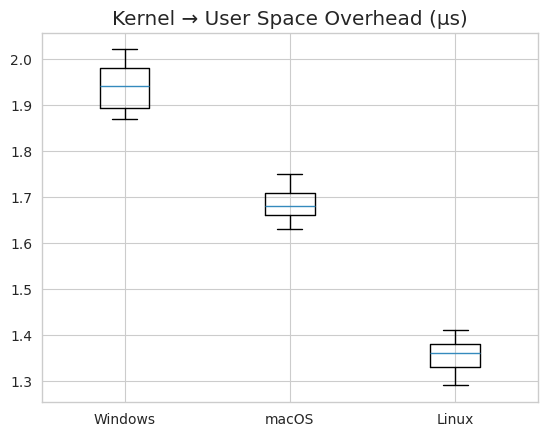

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([windows, macos, linux], labels=["Windows","macOS","Linux"])
plt.title("Kernel → User Space Overhead (µs)")
plt.show()